# Retention Overlap Plots

Generates overlap coefficient heatmaps showing how consistently each training point
is selected across different CDVM runs (budget sizes and datasets).

**Input:** `data/attr_datavals/*.npy` (binary selection vectors per CDVM run)  
**Output:** `output/` (overlap heatmaps)

In [1]:
from __future__ import annotations
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT_DIR   = Path.cwd() / 'data' / 'attr_datavals'
OUTPUT_DIR = Path.cwd() / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Filter (identisch zu anderen Notebooks) ───────────────────────────────────
FILTER_NUM_MODELS      = [10000]
FILTER_PROB            = [0.03]
FILTER_TIMESTAMP       = '20250919'
FILTER_TIMESTAMP_EXACT = False

DATASET_ORDER = ['cifar10-embeddings', 'bbc-embeddings', 'imdb-embeddings',
                 'nomao', 'pol', 'adult']

COLORS = {
    'gold':        '#f59e0b',
    'budget_crit': '#ef4444',
    'extended':    '#3b82f6',
    'rest':        '#94a3b8',
}

print('ROOT_DIR:', ROOT_DIR, '| exists =', ROOT_DIR.exists())

ROOT_DIR: /workspace/data/attr_datavals | exists = True


In [2]:
def parse_filename(path: Path) -> dict:
    parts = path.stem.split('-')
    out = {'dataset': None, 'budget': None, 'prob': None,
           'num_models': None, 'timestamp': None, 'ok': False}
    if len(parts) < 5:
        return out
    out['dataset']    = '-'.join(parts[:-4]).strip() or None
    out['budget']     = int(parts[-4]) if parts[-4].isdigit() else None
    out['prob']       = parts[-3]
    out['num_models'] = int(parts[-2]) if parts[-2].isdigit() else None
    out['timestamp']  = parts[-1]
    out['ok']         = True
    return out

def _norm_prob(v):
    try:    return f'{float(str(v).strip()):.12g}'
    except: return str(v).strip().lower()

def passes_filters(meta: dict) -> bool:
    if not meta['ok']: return False
    if FILTER_NUM_MODELS is not None:
        if meta['num_models'] not in set(FILTER_NUM_MODELS): return False
    if FILTER_PROB is not None:
        allowed = {_norm_prob(v) for v in (FILTER_PROB if isinstance(FILTER_PROB, (list, tuple)) else [FILTER_PROB])}
        if _norm_prob(meta['prob']) not in allowed: return False
    if FILTER_TIMESTAMP is not None:
        ts = str(meta['timestamp'] or '')
        tok = str(FILTER_TIMESTAMP)
        if FILTER_TIMESTAMP_EXACT and ts != tok: return False
        if not FILTER_TIMESTAMP_EXACT and tok not in ts: return False
    return True

all_files = sorted(ROOT_DIR.rglob('*.npy'))
files     = [p for p in all_files if passes_filters(parse_filename(p))]
print(f'Gefilterte .npy Dateien: {len(files)} / {len(all_files)}')

raw: dict[str, dict[int, list]] = defaultdict(lambda: defaultdict(list))
for p in files:
    meta = parse_filename(p)
    if not meta['ok'] or meta['dataset'] is None or meta['budget'] is None: continue
    try:
        arr = np.asarray(np.load(p, allow_pickle=True), dtype=float).reshape(-1)
    except Exception: continue
    if arr.size > 0:
        raw[meta['dataset']][meta['budget']].append(arr)

freq: dict[str, dict[int, np.ndarray]] = {}
for ds, bdict in raw.items():
    freq[ds] = {b: np.stack(runs).mean(axis=0) for b, runs in bdict.items()}

datasets_avail = [ds for ds in DATASET_ORDER if ds in freq]
print('Datasets:', datasets_avail)

Gefilterte .npy Dateien: 922 / 922


Datasets: ['cifar10-embeddings', 'bbc-embeddings', 'imdb-embeddings', 'nomao', 'pol', 'adult']


In [3]:
def consensus_set(f_vec: np.ndarray, budget: int) -> set:
    top_n = max(1, min(budget, len(f_vec)))
    return set(np.argpartition(f_vec, -top_n)[-top_n:].tolist())

cls: dict[str, dict] = {}
for ds in datasets_avail:
    budgets = sorted(freq[ds])
    b_min, b_max = budgets[0], budgets[-1]
    n   = len(freq[ds][b_min])
    n_B = len(budgets)
    C   = {b: consensus_set(freq[ds][b], b) for b in budgets}

    # Persistenz: in wie vielen consensus(B) taucht jeder Punkt auf?
    persist = np.zeros(n, dtype=int)
    for b in budgets:
        for idx in C[b]:
            persist[idx] += 1

    # Persistenz-basierte Zonen (konzeptuell sauber)
    never    = set(np.where(persist == 0)[0])          # nie in irgendeiner consensus-Menge
    bspec    = set(np.where(persist == 1)[0])          # exklusiv bei genau einem Budget
    useful   = set(np.where(persist >= 2)[0])          # bei mehreren Budgets nützlich
    gold     = set(np.where(persist == n_B)[0])        # bei ALLEN Budgets (Teilmenge von useful)

    # Alte Definitionen für Scatter-Plot-Kompatibilität
    b_crit = C[b_min] - C[b_max]
    ext    = C[b_max] - C[b_min]

    cls[ds] = {
        'budgets': budgets, 'C': C, 'n': n, 'n_B': n_B,
        'b_min': b_min, 'b_max': b_max,
        'persist': persist,
        # Persistenz-basiert
        'never': never, 'bspec': bspec, 'useful': useful, 'gold': gold,
        # Ranking-basiert (für Scatter-Achsenbeschriftung)
        'b_crit': b_crit, 'ext': ext,
        'rest': set(range(n)) - C[b_min] - C[b_max],
    }

print("Persistenz-Zonen (∅ über Datasets):")
for zone in ["never", "bspec", "useful"]:
    vals = [100 * len(cls[ds][zone]) / cls[ds]["n"] for ds in datasets_avail]
    print(f"  {zone:8s}: {np.mean(vals):.1f}% (range {min(vals):.1f}–{max(vals):.1f}%)")


Persistenz-Zonen (∅ über Datasets):
  never   : 64.5% (range 58.4–68.0%)
  bspec   : 9.4% (range 6.4–15.4%)
  useful  : 26.1% (range 25.5–27.1%)


## Main Paper — Overlap Coefficient Matrix

Gespeichert: /workspace/output/paper_overlap_coef_matrix.pdf


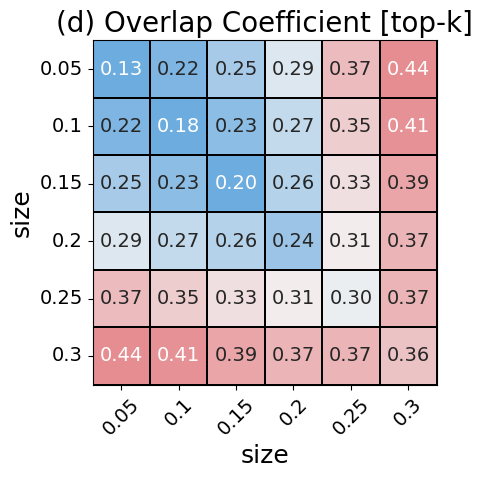

In [4]:
def _overlap_coef(a: set, b: set) -> float:
    denom = min(len(a), len(b))
    return len(a & b) / denom if denom > 0 else 0.0

def mean_overlap_matrix(ds: str):
    budgets_ds = sorted(raw[ds].keys())
    n_b = len(budgets_ds)
    M   = np.full((n_b, n_b), np.nan)
    for i, b_i in enumerate(budgets_ds):
        sets_i = [set(np.where(np.isclose(r, 1.0, atol=1e-9))[0]) for r in raw[ds][b_i]]
        for j, b_j in enumerate(budgets_ds):
            sets_j = [set(np.where(np.isclose(r, 1.0, atol=1e-9))[0]) for r in raw[ds][b_j]]
            vals = [_overlap_coef(A, B)
                    for mi, A in enumerate(sets_i)
                    for ni, B in enumerate(sets_j)
                    if not (i == j and mi == ni)]
            if vals:
                M[i, j] = float(np.mean(vals))
    return M, budgets_ds

matrices, size_sets = {}, []
for ds in datasets_avail:
    M, budgets_ds = mean_overlap_matrix(ds)
    matrices[ds] = (M, budgets_ds)
    size_sets.append(set(budgets_ds))

common = sorted(set.intersection(*size_sets))
n_ref  = len(freq[datasets_avail[0]][common[0]])
labels = [str(round(s / n_ref, 2)) for s in common]

mean_list = []
for ds in datasets_avail:
    M, budgets_ds = matrices[ds]
    idx = [budgets_ds.index(s) for s in common]
    mean_list.append(M[np.ix_(idx, idx)])
avg_overlap = np.nanmean(np.array(mean_list), axis=0)

# Camera-ready plot
soft_seismic = sns.diverging_palette(240, 10, s=65, l=68, center='light', as_cmap=True)
p10, p90 = float(np.nanpercentile(avg_overlap, 10)), float(np.nanpercentile(avg_overlap, 90))
vmin, vmax = max(0.0, p10 - 0.015), min(1.0, p90 + 0.015)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(avg_overlap, xticklabels=labels, yticklabels=labels,
            annot=True, fmt='.2f', cmap=soft_seismic,
            vmin=vmin, vmax=vmax, center=(vmin + vmax) / 2,
            ax=ax, cbar=False, linewidths=0.3, linecolor='black', square=True)
ax.set_title('(d) Overlap Coefficient [top-k]', fontsize=20)
ax.set_xlabel('size', fontsize=18)
ax.set_ylabel('size', fontsize=18)
ax.set_yticklabels(labels, rotation=0)
ax.set_xticklabels(labels, rotation=45)
for side in ['top', 'right', 'bottom', 'left']:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color('black')
plt.tight_layout()

out = OUTPUT_DIR / 'paper_overlap_coef_matrix.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
print('Gespeichert:', out)
plt.show()

## Appendix — Scatter Plot & Eviction-Rate Heatmap

Two plots illustrating the three-zone structure and budget-sensitivity of selected points.

Gespeichert: /workspace/output/appendix_scatter_fsmall_flarge.pdf


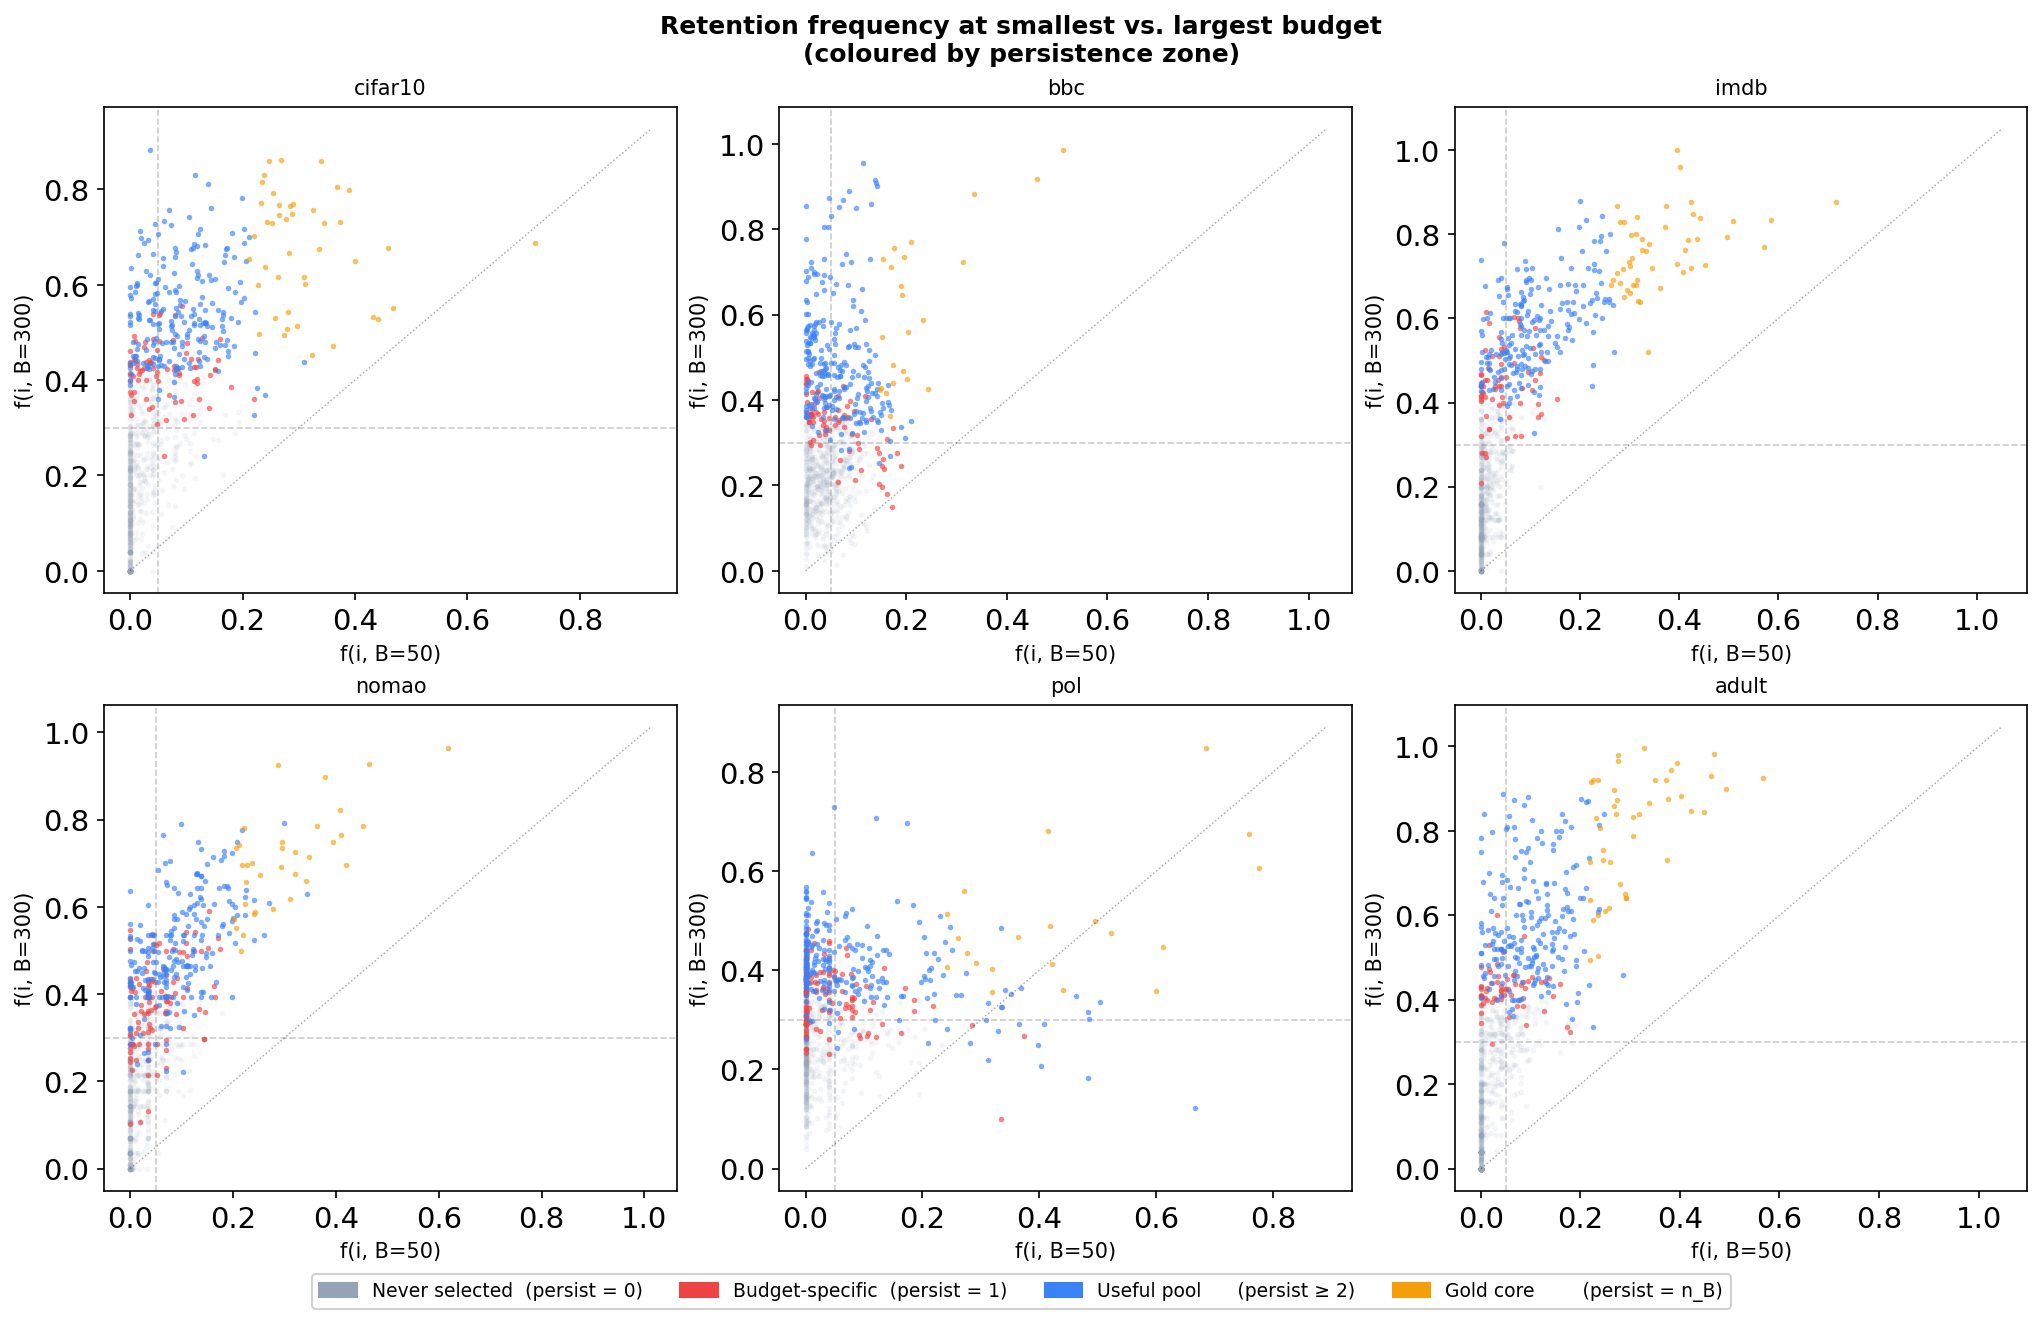

In [5]:
# ── Appendix Plot 1: Scatter f(i, B_small) vs f(i, B_large) ──────────────────
# Färbung nach Persistenz-Zonen (konzeptuell konsistent mit Paper-Text):
#   Grau  = never selected  (persist == 0)
#   Rot   = budget-specific (persist == 1)
#   Blau  = useful pool     (persist >= 2, nicht alle)
#   Gold  = gold core       (persist == n_B)

COLORS_P = {
    'never':   '#94a3b8',
    'bspec':   '#ef4444',
    'useful':  '#3b82f6',
    'gold':    '#f59e0b',
}

n_ds  = len(datasets_avail)
ncols = 3
nrows = int(np.ceil(n_ds / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.2 * nrows),
                         dpi=150, constrained_layout=True)
axes_flat = axes.flatten() if n_ds > 1 else [axes]

for ax, ds in zip(axes_flat, datasets_avail):
    r        = cls[ds]
    b_s, b_l = r['b_min'], r['b_max']
    f_small  = freq[ds][b_s]
    f_large  = freq[ds][b_l]
    n        = r['n']
    persist  = r['persist']
    n_B      = r['n_B']

    # Farbe nach Persistenz-Zone
    colors = np.empty(n, dtype=object)
    colors[persist == 0]  = COLORS_P['never']
    colors[persist == 1]  = COLORS_P['bspec']
    colors[(persist >= 2) & (persist < n_B)] = COLORS_P['useful']
    colors[persist == n_B] = COLORS_P['gold']

    # Reihenfolge: unwichtige Punkte zuerst (im Hintergrund)
    order = np.argsort(persist)
    for i in order:
        alpha = 0.10 if persist[i] == 0 else 0.65
        ax.scatter(f_small[i], f_large[i], c=colors[i], s=7,
                   alpha=alpha, linewidths=0, rasterized=True)

    ax.axvline(b_s / n, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.axhline(b_l / n, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
    lim = max(f_small.max(), f_large.max()) * 1.05
    ax.plot([0, lim], [0, lim], color='black', linewidth=0.7, linestyle=':', alpha=0.35)
    ax.set_xlabel(f'f(i, B={b_s})', fontsize=10)
    ax.set_ylabel(f'f(i, B={b_l})', fontsize=10)
    ax.set_title(ds.replace('-embeddings', ''), fontsize=10)

for ax in axes_flat[n_ds:]:
    ax.set_visible(False)

handles = [
    mpatches.Patch(color=COLORS_P['never'],  label='Never selected  (persist = 0)'),
    mpatches.Patch(color=COLORS_P['bspec'],  label='Budget-specific  (persist = 1)'),
    mpatches.Patch(color=COLORS_P['useful'], label='Useful pool      (persist ≥ 2)'),
    mpatches.Patch(color=COLORS_P['gold'],   label='Gold core        (persist = n_B)'),
]
fig.legend(handles=handles, fontsize=9, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
fig.suptitle('Retention frequency at smallest vs. largest budget\n(coloured by persistence zone)',
             fontsize=12, fontweight='bold')

out = OUTPUT_DIR / 'appendix_scatter_fsmall_flarge.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
print('Gespeichert:', out)
plt.show()


Gespeichert: /workspace/output/appendix_eviction_overlap_heatmap.pdf


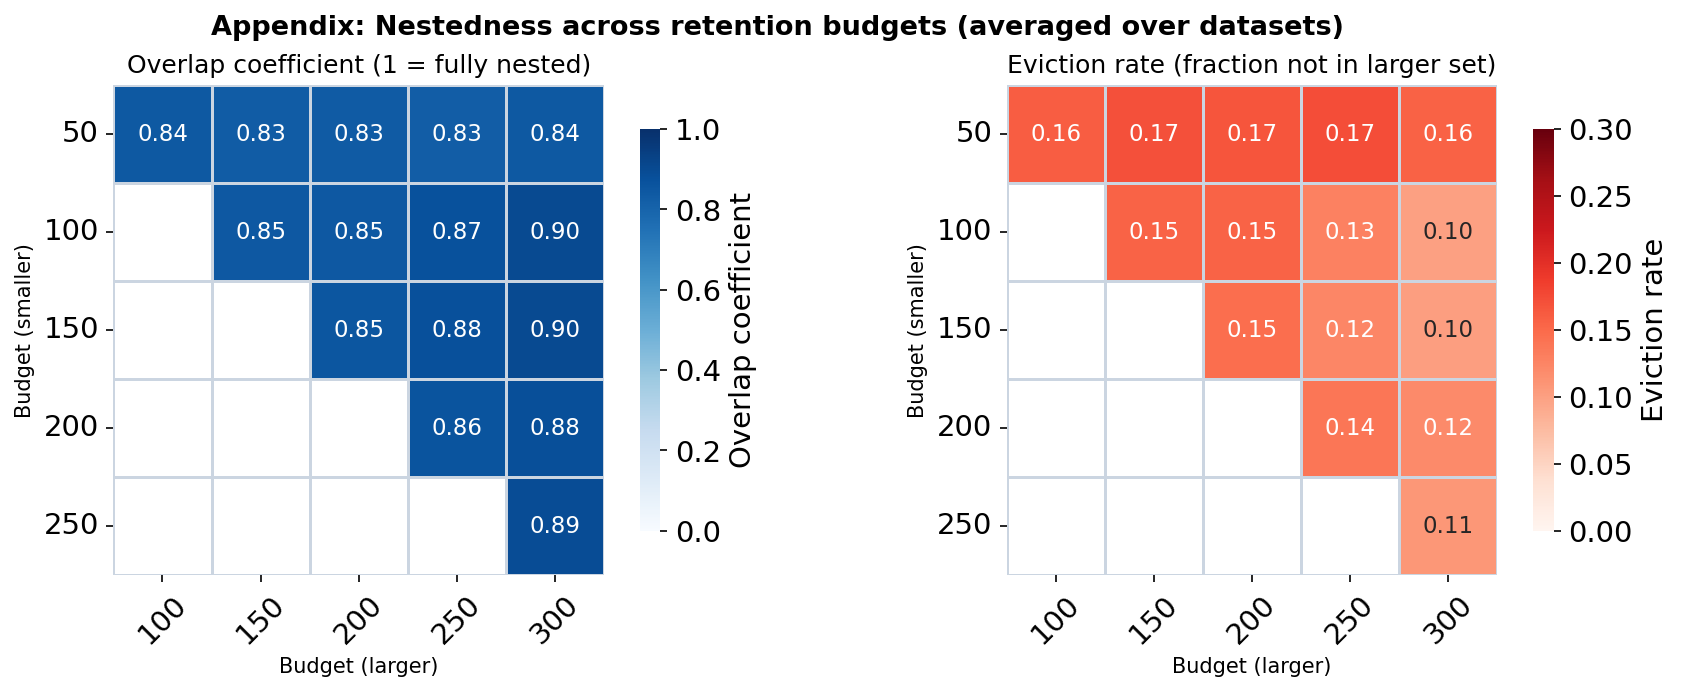


Eviction Rate (∅ über Datasets):
B_large   100    150    200    250    300
B_small                                  
50       0.16  0.170  0.167  0.173  0.157
100       NaN  0.155  0.155  0.128  0.100
150       NaN    NaN  0.146  0.123  0.101
200       NaN    NaN    NaN  0.139  0.120
250       NaN    NaN    NaN    NaN  0.109


In [6]:
# ── Appendix Plot 2: Eviction-Rate-Heatmap ───────────────────────────────────
# Zeigt den budget-spezifischen Anteil (~10-16%) über alle Budget-Paare

stacking_rows = []
for ds in datasets_avail:
    r = cls[ds]
    budgets_ds = r['budgets']
    C = r['C']
    for i, b_s in enumerate(budgets_ds):
        for j, b_l in enumerate(budgets_ds):
            if j <= i: continue
            inter    = len(C[b_s] & C[b_l])
            eviction = 1 - inter / len(C[b_s]) if len(C[b_s]) > 0 else np.nan
            overlap  = inter / min(len(C[b_s]), len(C[b_l])) if min(len(C[b_s]), len(C[b_l])) > 0 else np.nan
            stacking_rows.append({'dataset': ds, 'B_small': b_s, 'B_large': b_l,
                                  'eviction_rate': round(eviction, 3),
                                  'overlap_coef':  round(overlap, 3)})

df_stack       = pd.DataFrame(stacking_rows)
pivot_eviction = df_stack.groupby(['B_small','B_large'])['eviction_rate'].mean().unstack('B_large')
pivot_overlap  = df_stack.groupby(['B_small','B_large'])['overlap_coef'].mean().unstack('B_large')

hm_kws = dict(annot=True, fmt='.2f', linewidths=0.5, linecolor='#cbd5e1',
              square=True, annot_kws={'size': 11})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150, constrained_layout=True)

sns.heatmap(pivot_overlap,  ax=axes[0], cmap='Blues',  vmin=0, vmax=1, **hm_kws,
            cbar_kws={'shrink': 0.82, 'label': 'Overlap coefficient'})
axes[0].set_title('Overlap coefficient (1 = fully nested)', fontsize=12)
axes[0].set_xlabel('Budget (larger)', fontsize=10)
axes[0].set_ylabel('Budget (smaller)', fontsize=10)

sns.heatmap(pivot_eviction, ax=axes[1], cmap='Reds',   vmin=0, vmax=0.3, **hm_kws,
            cbar_kws={'shrink': 0.82, 'label': 'Eviction rate'})
axes[1].set_title('Eviction rate (fraction not in larger set)', fontsize=12)
axes[1].set_xlabel('Budget (larger)', fontsize=10)
axes[1].set_ylabel('Budget (smaller)', fontsize=10)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Appendix: Nestedness across retention budgets (averaged over datasets)',
             fontsize=13, fontweight='bold')

out = OUTPUT_DIR / 'appendix_eviction_overlap_heatmap.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
print('Gespeichert:', out)
plt.show()

print()
print('Eviction Rate (∅ über Datasets):')
print(pivot_eviction.round(3).to_string())

## Three-Zone Summary

Persistenz-basierte Drei-Zonen-Struktur:
Dataset                       Never    Useful      Gold    B-spec
--------------------------------------------------------------------
cifar10                       66.1%     25.9%      4.3%      8.0%
bbc                           64.7%     27.1%      2.3%      8.2%
imdb                          67.8%     25.5%      4.8%      6.7%
nomao                         61.9%     26.5%      3.4%     11.6%
pol                           58.4%     26.2%      2.0%     15.4%
adult                         68.0%     25.6%      4.4%      6.4%


Gespeichert: /workspace/output/appendix_three_zone_summary.pdf


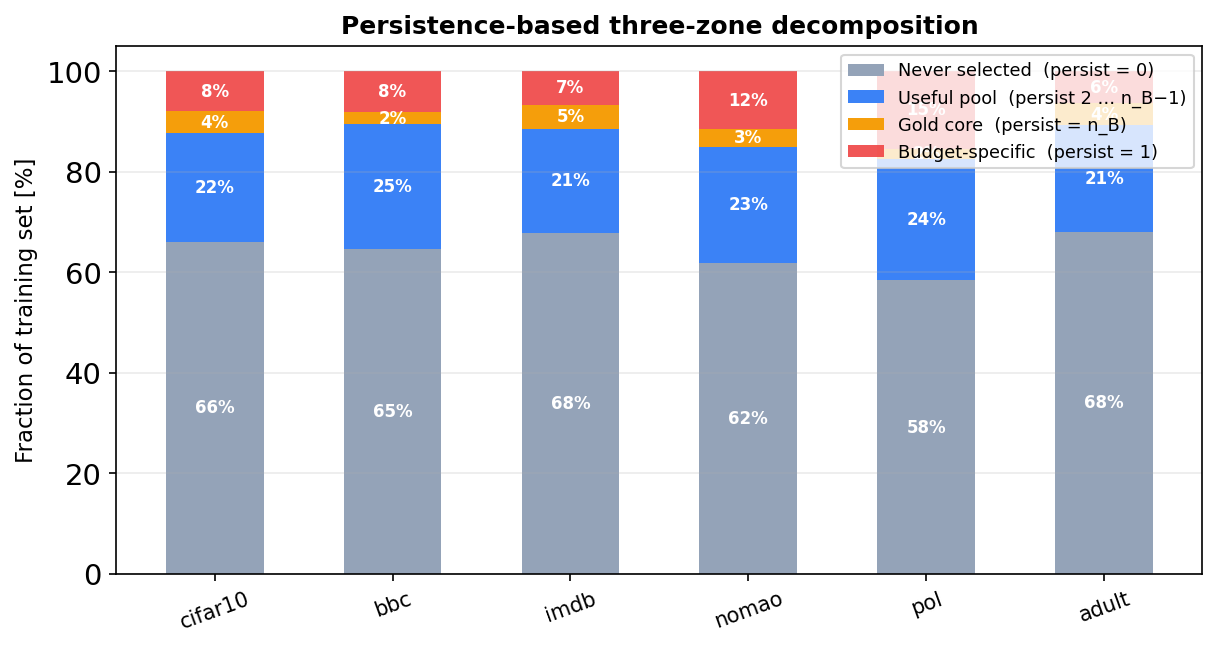

In [7]:
# ── Drei-Zonen-Tabelle & Bar Chart (Persistenz-basiert) ──────────────────────

COLORS_P = {
    'never':  '#94a3b8',
    'bspec':  '#ef4444',
    'useful': '#3b82f6',
    'gold':   '#f59e0b',
}

zone_rows = []
for ds in datasets_avail:
    r   = cls[ds]
    n   = r['n']
    n_never  = len(r['never'])
    n_useful = len(r['useful'])
    n_gold   = len(r['gold'])
    n_bspec  = len(r['bspec'])
    zone_rows.append({
        'ds':              ds,
        'label':           ds.replace('-embeddings', ''),
        'never_%':         round(100 * n_never  / n, 1),
        'useful_%':        round(100 * n_useful / n, 1),
        'gold_%':          round(100 * n_gold   / n, 1),
        'useful_no_gold_%':round(100 * (n_useful - n_gold) / n, 1),
        'bspec_%':         round(100 * n_bspec  / n, 1),
        'never_n':  n_never,  'useful_n': n_useful,
        'gold_n':   n_gold,   'bspec_n':  n_bspec,
    })

# Tabelle
print("Persistenz-basierte Drei-Zonen-Struktur:")
print(f"{'Dataset':25s}  {'Never':>8s}  {'Useful':>8s}  {'  Gold':>8s}  {'B-spec':>8s}")
print('-' * 68)
for r in zone_rows:
    print(f"{r['label']:25s}  {r['never_%']:7.1f}%  {r['useful_%']:7.1f}%"
          f"  {r['gold_%']:7.1f}%  {r['bspec_%']:7.1f}%")

# ── Bar Chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.2), dpi=150, constrained_layout=True)

x = np.arange(len(zone_rows))
w = 0.55

pn  = [r['never_%']          for r in zone_rows]
pu  = [r['useful_no_gold_%'] for r in zone_rows]
pg  = [r['gold_%']           for r in zone_rows]
pb  = [r['bspec_%']          for r in zone_rows]
lbl = [r['label']            for r in zone_rows]

bot_u = pn
bot_g = [a + b for a, b in zip(bot_u, pu)]
bot_b = [a + b for a, b in zip(bot_g, pg)]

b1 = ax.bar(x, pn, w, color=COLORS_P['never'],  label='Never selected  (persist = 0)')
b2 = ax.bar(x, pu, w, bottom=bot_u, color=COLORS_P['useful'], label='Useful pool  (persist 2 … n_B−1)')
b3 = ax.bar(x, pg, w, bottom=bot_g, color=COLORS_P['gold'],   label='Gold core  (persist = n_B)')
b4 = ax.bar(x, pb, w, bottom=bot_b, color=COLORS_P['bspec'],  label='Budget-specific  (persist = 1)', alpha=0.9)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        h = bar.get_height()
        if h >= 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + h / 2,
                    f'{h:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(lbl, rotation=20, fontsize=10)
ax.set_ylabel('Fraction of training set [%]', fontsize=11)
ax.set_ylim(0, 105)
ax.legend(fontsize=8.5, loc='upper right')
ax.grid(axis='y', alpha=0.25)
ax.set_title('Persistence-based three-zone decomposition', fontsize=12, fontweight='bold')

out = OUTPUT_DIR / 'appendix_three_zone_summary.pdf'
fig.savefig(out, format='pdf', bbox_inches='tight')
print('Gespeichert:', out)
plt.show()


## Budget-Sensitive Instances — Threshold Analysis

Which points are selected at some budgets but not others?

In [8]:
# ── Threshold-basierte Persistenz (f(i,B) > 0.5) ─────────────────────────────
# n_above[ds][i] = Anzahl Budgets, bei denen Punkt i von >50% der Seeds gewählt

THRESH = 0.5

n_above = {}
freq_mat = {}   # freq_mat[ds]: array (n_B, n)

for ds in datasets_avail:
    budgets = sorted(freq[ds])
    n_B_ds  = len(budgets)
    n_ds    = len(freq[ds][budgets[0]])
    mat     = np.array([freq[ds][b] for b in budgets])   # (n_B, n)
    freq_mat[ds]  = mat
    n_above[ds]   = (mat > THRESH).sum(axis=0)           # (n,)

print(f"Threshold: f > {THRESH}\n")
print(f"{'Dataset':22s} | {'Stable-Out':>10s} | {'Mobile':>8s} | {'Stable-In':>9s} | {'Mobile%':>7s}")
print("-" * 68)
for ds in datasets_avail:
    na  = n_above[ds]
    n   = len(na)
    n_B_ds = freq_mat[ds].shape[0]
    so  = (na == 0).sum()
    si  = (na == n_B_ds).sum()
    mob = n - so - si
    print(f"{ds:22s} | {so:10d} | {mob:8d} | {si:9d} | {100*mob/n:6.1f}%")


Threshold: f > 0.5

Dataset                | Stable-Out |   Mobile | Stable-In | Mobile%
--------------------------------------------------------------------
cifar10-embeddings     |        810 |      189 |         1 |   18.9%
bbc-embeddings         |        890 |      109 |         1 |   10.9%
imdb-embeddings        |        777 |      219 |         4 |   21.9%
nomao                  |        842 |      157 |         1 |   15.7%
pol                    |        959 |       38 |         3 |    3.8%
adult                  |        798 |      201 |         1 |   20.1%


### Option C — Stacked Bar Chart (3 Categories, Threshold-based)

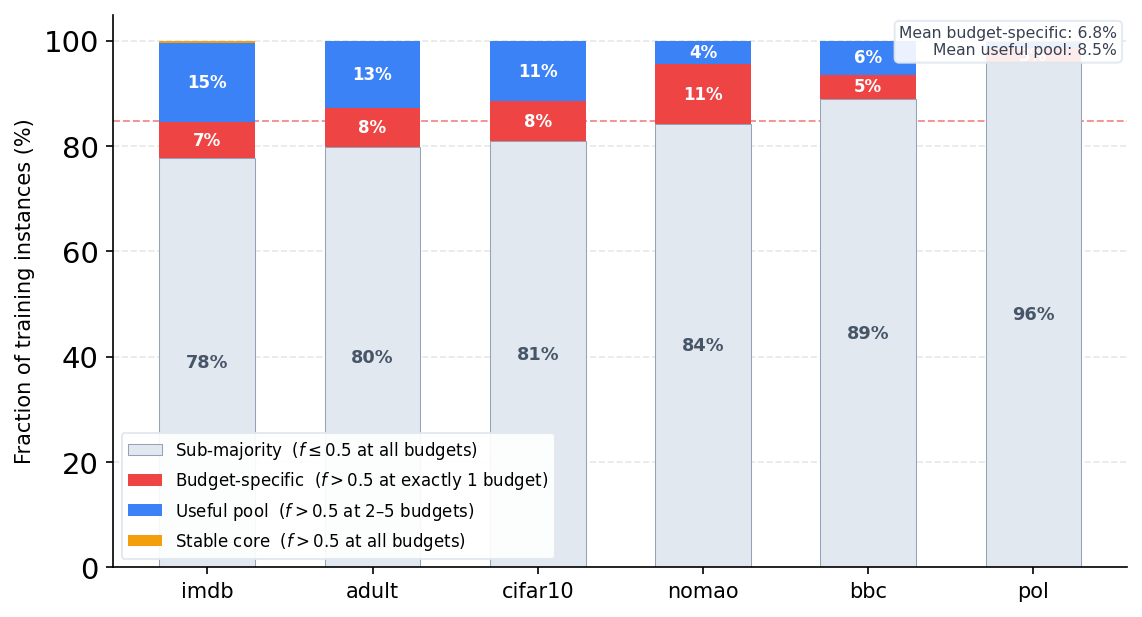


Dataset                | Sub-maj. |  B-Spec |  Useful |   Core
--------------------------------------------------------------
imdb-embeddings        |    77.7% |    6.8% |   15.1% |  0.40%
adult                  |    79.8% |    7.5% |   12.6% |  0.10%
cifar10-embeddings     |    81.0% |    7.5% |   11.4% |  0.10%
nomao                  |    84.2% |   11.4% |    4.3% |  0.10%
bbc-embeddings         |    89.0% |    4.6% |    6.3% |  0.10%
pol                    |    95.9% |    2.7% |    1.1% |  0.30%

Means: sub-maj=84.6%  b-spec=6.8%  useful=8.5%  core=0.18%

Saved option_c_threshold_zones.pdf


In [9]:
# ── Option C: Bar Chart — Threshold-basierte Kategorien (aufgewertet) ─────────
DS_LABELS = [d.replace("-embeddings", "") for d in datasets_avail]

sub_majority_pct, bspec_t_pct, useful_t_pct, stable_in_pct = [], [], [], []

for ds in datasets_avail:
    na     = n_above[ds]
    n      = len(na)
    n_B_ds = freq_mat[ds].shape[0]
    sub_majority_pct.append(100 * (na == 0).sum()                     / n)
    bspec_t_pct.append(     100 * (na == 1).sum()                     / n)
    useful_t_pct.append(    100 * ((na >= 2) & (na < n_B_ds)).sum()   / n)
    stable_in_pct.append(   100 * (na == n_B_ds).sum()                / n)

# Sort datasets by mobile fraction (budget-specific + useful) descending
mobile_total = [bs + up for bs, up in zip(bspec_t_pct, useful_t_pct)]
order = sorted(range(len(datasets_avail)), key=lambda i: mobile_total[i], reverse=True)

ds_ordered  = [datasets_avail[i] for i in order]
lbl_ordered = [DS_LABELS[i]      for i in order]
so  = [sub_majority_pct[i] for i in order]
bs  = [bspec_t_pct[i]      for i in order]
up  = [useful_t_pct[i]     for i in order]
si  = [stable_in_pct[i]    for i in order]

x = np.arange(len(datasets_avail))
w = 0.58

C_SO = "#e2e8f0"   # sub-majority   (very light gray)
C_BS = "#ef4444"   # budget-specific (red)
C_UP = "#3b82f6"   # useful pool     (blue)
C_SI = "#f59e0b"   # stable core     (gold)

fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=150, constrained_layout=True)

bot_bs = so
bot_up = [a + b for a, b in zip(so, bs)]
bot_si = [a + b + c for a, b, c in zip(so, bs, up)]

b1 = ax.bar(x, so, w, color=C_SO, edgecolor="#94a3b8", linewidth=0.5,
            label=r"Sub-majority  ($f \leq 0.5$ at all budgets)")
b2 = ax.bar(x, bs, w, bottom=bot_bs, color=C_BS,
            label=r"Budget-specific  ($f > 0.5$ at exactly 1 budget)")
b3 = ax.bar(x, up, w, bottom=bot_up, color=C_UP,
            label=r"Useful pool  ($f > 0.5$ at 2–5 budgets)")
b4 = ax.bar(x, si, w, bottom=bot_si, color=C_SI,
            label=r"Stable core  ($f > 0.5$ at all budgets)")

# In-bar labels
for xi in range(len(ds_ordered)):
    # sub-majority
    ax.text(xi, so[xi]/2, f"{so[xi]:.0f}%", ha="center", va="center",
            fontsize=8.5, fontweight="bold", color="#475569")
    # budget-specific
    if bs[xi] > 1.8:
        ax.text(xi, bot_bs[xi] + bs[xi]/2, f"{bs[xi]:.0f}%", ha="center", va="center",
                fontsize=8, fontweight="bold", color="white")
    # useful pool
    if up[xi] > 1.8:
        ax.text(xi, bot_up[xi] + up[xi]/2, f"{up[xi]:.0f}%", ha="center", va="center",
                fontsize=8, fontweight="bold", color="white")

# Mean lines for budget-specific and useful pool
mean_bs = np.mean(bspec_t_pct)
mean_up = np.mean(useful_t_pct)
ax.axhline(100 - mean_up - mean_bs, color=C_BS, linewidth=0.9,
           linestyle="--", alpha=0.6, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(lbl_ordered, fontsize=10)
ax.set_ylabel("Fraction of training instances (%)", fontsize=10)
ax.set_ylim(0, 105)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(loc="lower left", fontsize=8, frameon=True,
          framealpha=0.92, edgecolor="#e2e8f0")

# Summary annotation
ax.text(0.99, 0.98,
        f"Mean budget-specific: {mean_bs:.1f}%\nMean useful pool: {mean_up:.1f}%",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
        color="#374151", bbox=dict(boxstyle="round,pad=0.3", fc="white",
                                   ec="#e2e8f0", alpha=0.9))

plt.savefig(OUTPUT_DIR / "option_c_threshold_zones.pdf", bbox_inches="tight")
plt.show()

print(f"\n{'Dataset':22s} | {'Sub-maj.':>8s} | {'B-Spec':>7s} | {'Useful':>7s} | {'Core':>6s}")
print("-" * 62)
for ds, a, b_, c, d in zip(ds_ordered, so, bs, up, si):
    print(f"{ds:22s} | {a:7.1f}% | {b_:6.1f}% | {c:6.1f}% | {d:5.2f}%")
print(f"\nMeans: sub-maj={np.mean(sub_majority_pct):.1f}%  "
      f"b-spec={mean_bs:.1f}%  useful={mean_up:.1f}%  core={np.mean(stable_in_pct):.2f}%")
print("\nSaved option_c_threshold_zones.pdf")


### Option D — Violin Plot f(i,B) per Budget

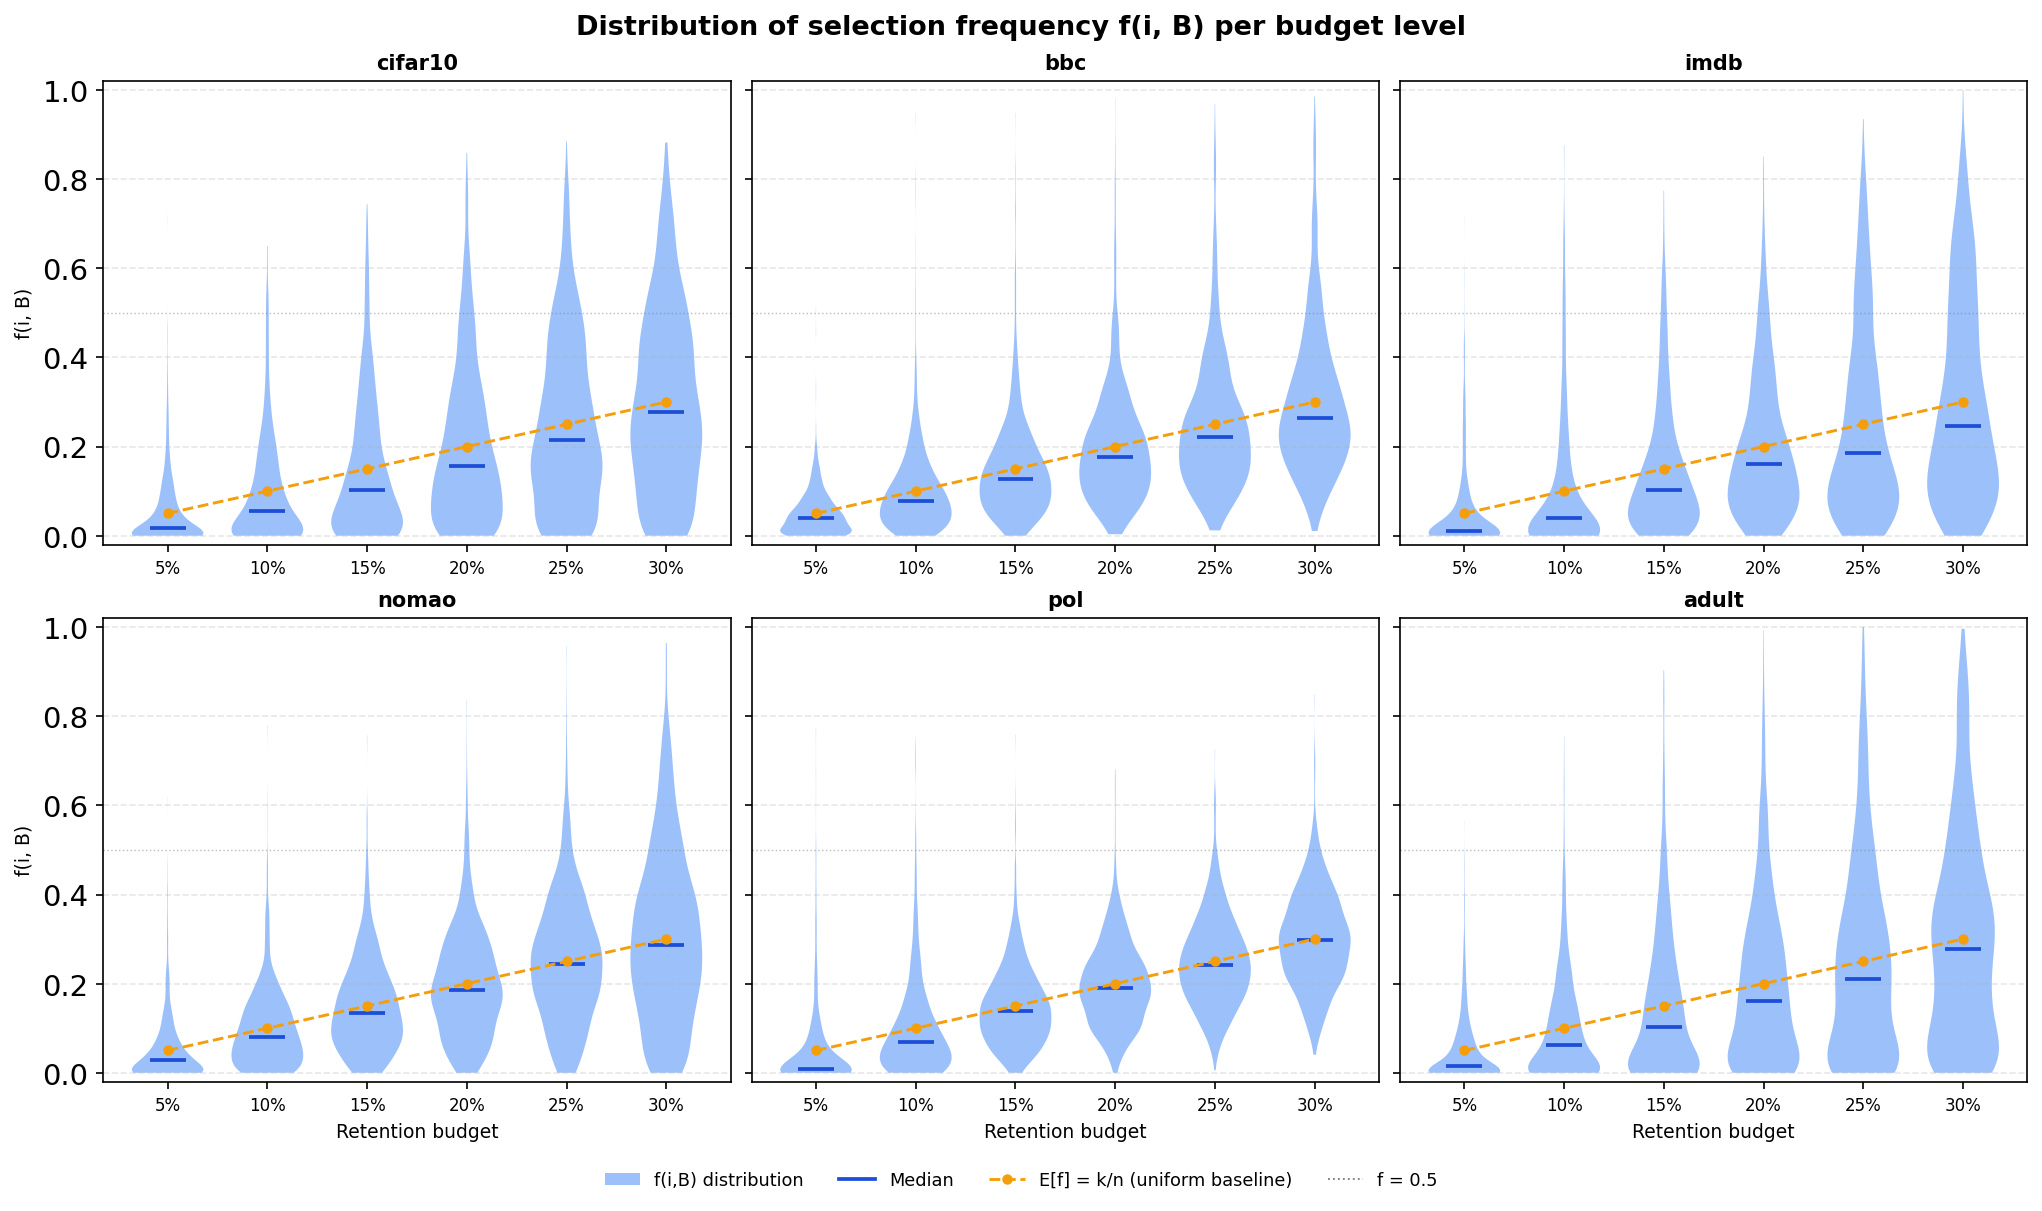

Saved option_d_violin_f_distribution.pdf


In [10]:
# ── Option D: Violinplot f(i,B) — pro Dataset × Budget ──────────────────────
budgets_abs  = [50, 100, 150, 200, 250, 300]
budget_labels = ["5%", "10%", "15%", "20%", "25%", "30%"]
DS_LABELS    = [d.replace("-embeddings", "") for d in datasets_avail]

n_ds   = len(datasets_avail)
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.8 * n_rows),
                         dpi=150, sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for ax, ds, lbl in zip(axes_flat, datasets_avail, DS_LABELS):
    mat = freq_mat[ds]                      # (n_B, n)
    vdata = [mat[i].tolist() for i in range(mat.shape[0])]

    parts = ax.violinplot(vdata, positions=range(len(budgets_abs)),
                          showmedians=True, showextrema=False, widths=0.72)
    for pc in parts["bodies"]:
        pc.set_facecolor("#3b82f6")
        pc.set_alpha(0.50)
    parts["cmedians"].set_color("#1d4ed8")
    parts["cmedians"].set_linewidth(1.8)

    # E[f] = k/n baseline
    expected = [b / 1000 for b in budgets_abs]
    ax.plot(range(len(budgets_abs)), expected, "o--", color="#f59e0b",
            linewidth=1.4, markersize=4, zorder=3)

    ax.axhline(0.5, color="gray", linewidth=0.7, linestyle=":", alpha=0.5)
    ax.set_xticks(range(len(budgets_abs)))
    ax.set_xticklabels(budget_labels, fontsize=8)
    ax.set_title(lbl, fontsize=10, fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    if ax in axes[:, 0]:
        ax.set_ylabel("f(i, B)", fontsize=9)
    if ax in axes[-1]:
        ax.set_xlabel("Retention budget", fontsize=9)

fig.suptitle("Distribution of selection frequency f(i, B) per budget level",
             fontsize=13, fontweight="bold")

# Shared legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Patch(facecolor="#3b82f6", alpha=0.5, label="f(i,B) distribution"),
    Line2D([0],[0], color="#1d4ed8", linewidth=1.8, label="Median"),
    Line2D([0],[0], color="#f59e0b", marker="o", linestyle="--",
           linewidth=1.4, markersize=4, label="E[f] = k/n (uniform baseline)"),
    Line2D([0],[0], color="gray", linestyle=":", linewidth=0.9, label="f = 0.5"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.savefig(OUTPUT_DIR / "option_d_violin_f_distribution.pdf", bbox_inches="tight")
plt.show()
print("Saved option_d_violin_f_distribution.pdf")


### Option E — Diverging Bar Plot (Frequency Spectrum)

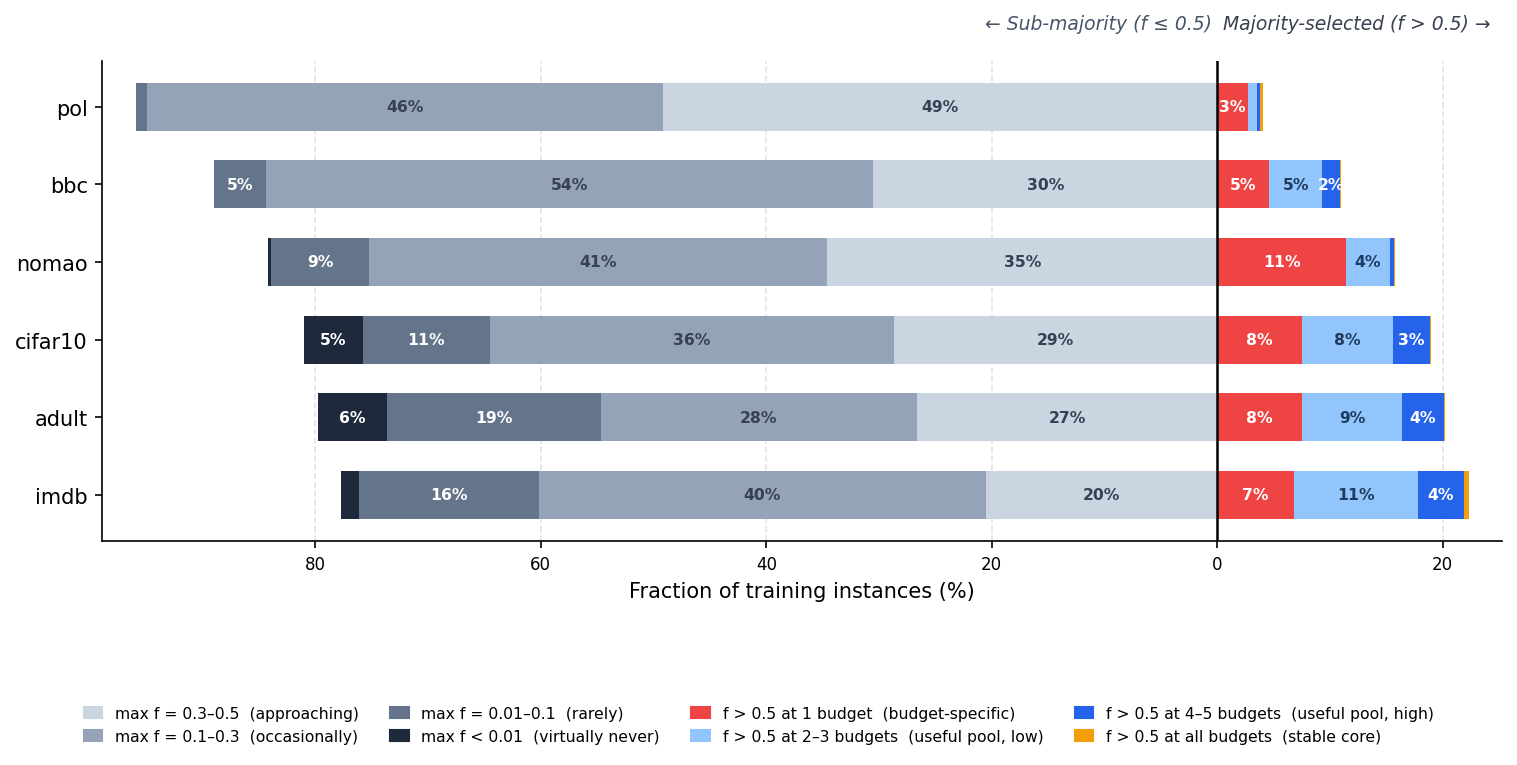

Saved option_e_diverging_spectrum.pdf


In [11]:
# ── Option E: Divergierender Barplot — vollständiges Frequenzspektrum ─────────
# Useful pool aufgeteilt in: f>0.5 bei 2-3 Budgets (hellblau) vs 4-5 (dunkelblau)

C_VNEV   = "#1e293b"   # max_f < 0.01
C_RARE   = "#64748b"   # max_f 0.01–0.1
C_OCC    = "#94a3b8"   # max_f 0.1–0.3
C_APPR   = "#cbd5e1"   # max_f 0.3–0.5
C_BSPEC  = "#ef4444"   # n_above = 1
C_POOL_LO= "#93c5fd"   # n_above = 2–3  (hellblau)
C_POOL_HI= "#2563eb"   # n_above = 4–5  (dunkelblau)
C_CORE   = "#f59e0b"   # n_above = 6

rows = []
for ds in datasets_avail:
    mat   = freq_mat[ds]
    na    = n_above[ds]
    max_f = mat.max(axis=0)
    n     = len(na)
    n_B   = mat.shape[0]
    sub   = (na == 0)
    rows.append({
        'ds':      ds,
        'lbl':     ds.replace("-embeddings", ""),
        'vnev':    100*(sub&(max_f< 0.01)).sum()/n,
        'rare':    100*(sub&(max_f>=0.01)&(max_f<0.10)).sum()/n,
        'occ':     100*(sub&(max_f>=0.10)&(max_f<0.30)).sum()/n,
        'appr':    100*(sub&(max_f>=0.30)).sum()/n,
        'bspec':   100*(na==1).sum()/n,
        'pool_lo': 100*((na>=2)&(na<=3)).sum()/n,
        'pool_hi': 100*((na>=4)&(na<=n_B-1)).sum()/n,
        'core':    100*(na==n_B).sum()/n,
    })

rows.sort(key=lambda r: r["bspec"]+r["pool_lo"]+r["pool_hi"]+r["core"], reverse=True)

fig, ax = plt.subplots(figsize=(10, 4.0), dpi=150, constrained_layout=True)

y = np.arange(len(rows))
h = 0.62

for yi, r in enumerate(rows):
    # Left side (sub-majority, going left; approaching closest to center)
    left_segs = [
        (0,                                    -r["appr"],  C_APPR),
        (-r["appr"],                           -r["occ"],   C_OCC),
        (-(r["appr"]+r["occ"]),                -r["rare"],  C_RARE),
        (-(r["appr"]+r["occ"]+r["rare"]),      -r["vnev"],  C_VNEV),
    ]
    for left, width, color in left_segs:
        if abs(width) > 0.05:
            ax.barh(yi, width, h, left=left, color=color, linewidth=0)

    # Right side (majority, going right; budget-specific closest to center)
    right_segs = [
        (0,                                                  r["bspec"],   C_BSPEC),
        (r["bspec"],                                         r["pool_lo"], C_POOL_LO),
        (r["bspec"]+r["pool_lo"],                            r["pool_hi"], C_POOL_HI),
        (r["bspec"]+r["pool_lo"]+r["pool_hi"],               r["core"],   C_CORE),
    ]
    for left, width, color in right_segs:
        if abs(width) > 0.05:
            ax.barh(yi, width, h, left=left, color=color, linewidth=0)

    # Labels left
    cum = 0
    for width, color in [(r["appr"],C_APPR),(r["occ"],C_OCC),
                          (r["rare"],C_RARE),(r["vnev"],C_VNEV)]:
        if width > 2.5:
            ax.text(-(cum+width/2), yi, f"{width:.0f}%", ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color="white" if color in [C_RARE,C_VNEV] else "#374151")
        cum += width

    # Labels right
    cum = 0
    for width, color in [(r["bspec"],C_BSPEC),(r["pool_lo"],C_POOL_LO),
                          (r["pool_hi"],C_POOL_HI),(r["core"],C_CORE)]:
        if width > 1.5:
            ax.text(cum+width/2, yi, f"{width:.0f}%", ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color="white" if color in [C_BSPEC,C_POOL_HI] else "#1e3a5f")
        cum += width

ax.axvline(0, color="black", linewidth=1.2, zorder=5)
ax.set_yticks(y)
ax.set_yticklabels([r["lbl"] for r in rows], fontsize=10)
ax.set_xlabel("Fraction of training instances (%)", fontsize=10)

max_left = max(r["vnev"]+r["rare"]+r["occ"]+r["appr"] for r in rows)
max_right = max(r["bspec"]+r["pool_lo"]+r["pool_hi"]+r["core"] for r in rows)
xticks = np.arange(-80, 30, 20)
ax.set_xticks(xticks)
ax.set_xticklabels([str(abs(int(v))) for v in xticks], fontsize=8)
ax.set_xlim(-max_left-3, max_right+3)

ax.xaxis.grid(True, linestyle="--", alpha=0.35, zorder=0)
ax.set_axisbelow(True)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.text(-0.5, len(rows)-0.05, "← Sub-majority (f ≤ 0.5)",
        ha="right", va="bottom", fontsize=9, color="#475569", style="italic")
ax.text( 0.5, len(rows)-0.05, "Majority-selected (f > 0.5) →",
        ha="left",  va="bottom", fontsize=9, color="#374151", style="italic")

from matplotlib.patches import Patch
handles = [
    Patch(color=C_APPR,    label="max f = 0.3–0.5  (approaching)"),
    Patch(color=C_OCC,     label="max f = 0.1–0.3  (occasionally)"),
    Patch(color=C_RARE,    label="max f = 0.01–0.1  (rarely)"),
    Patch(color=C_VNEV,    label="max f < 0.01  (virtually never)"),
    Patch(color=C_BSPEC,   label="f > 0.5 at 1 budget  (budget-specific)"),
    Patch(color=C_POOL_LO, label="f > 0.5 at 2–3 budgets  (useful pool, low)"),
    Patch(color=C_POOL_HI, label="f > 0.5 at 4–5 budgets  (useful pool, high)"),
    Patch(color=C_CORE,    label="f > 0.5 at all budgets  (stable core)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7.5,
           bbox_to_anchor=(0.5, -0.25), frameon=False, handlelength=1.2)

plt.savefig(OUTPUT_DIR / "option_e_diverging_spectrum.pdf", bbox_inches="tight")
plt.show()
print("Saved option_e_diverging_spectrum.pdf")
